<a href="https://colab.research.google.com/github/lissettzuniga/data-science-course/blob/main/projects/telecom_x_churn_analysis/Telecom%20X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X - Customer Churn Analysis**

## Objective

Telecom X is experiencing a high rate of customer cancellations (churn).  
The objective of this project is to analyze customer data to identify patterns and factors associated with churn.

This analysis includes:

- Data extraction from an API
- Data cleaning and transformation (ETL)
- Exploratory Data Analysis (EDA)
- Data visualization
- Business insights to help reduce customer churn

#📌 Extraction

## Data Extraction

In this step, we load the Telecom X dataset directly from a public JSON file hosted on GitHub.
The data will be converted into a pandas DataFrame for further analysis.

In [1]:
import pandas as pd

In [3]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [7]:
data = pd.read_json(url)
data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transform

The dataset contains nested JSON structures in the columns:

- customer
- phone
- internet
- account

To make the dataset suitable for analysis, these nested fields are normalized into separate columns using `pd.json_normalize()`.

In [8]:
customer = pd.json_normalize(data['customer'])
phone = pd.json_normalize(data['phone'])
internet = pd.json_normalize(data['internet'])
account = pd.json_normalize(data['account'])

In [9]:
df = pd.concat(
    [data[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

## Data Cleaning

In this step, we check the dataset for potential issues that may affect the analysis.

We will verify:

- Missing values
- Duplicate records
- Incorrect data types
- Category inconsistencies

Cleaning the dataset ensures the reliability of the exploratory data analysis.

In [11]:
df.shape

(7267, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [13]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [17]:
df['Charges.Total'].dtype

dtype('O')

In [20]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

In [21]:
df['Charges.Total'].dtype

dtype('float64')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [23]:
df = df.dropna()

In [25]:
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [26]:
df.columns = df.columns.str.replace('.', '_')

In [27]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## Feature Engineering

To gain a more detailed view of customer spending behavior, we create a new column called **Cuentas_Diarias**.

This column represents the estimated daily cost of the service based on the monthly charges.

Cuentas_Diarias = MonthlyCharges / 30

In [32]:
df['Cuentas_Diarias'] = (df['Charges_Monthly'] / 30).round(2)

In [33]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


## Data Standardization

To improve the consistency and usability of the dataset, some variables are standardized.

The following transformations are applied:

- Converting categorical values such as "Yes" and "No" into binary values (1 and 0)
- Renaming columns to improve readability and consistency

In [34]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [35]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [36]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [37]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Analysis

## Descriptive Data Analysis

In this step, we analyze the dataset using descriptive statistics to better understand customer behavior.

We calculate metrics such as:

- Mean
- Median
- Standard deviation
- Minimum and maximum values

These metrics help us understand the distribution of numeric variables such as tenure, monthly charges, and total charges.

In [38]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158467
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004282
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.180000
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,3.000000
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [40]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].mean()

,0
tenure,32.395535
Charges_Monthly,64.755423
Charges_Total,2280.634213
Cuentas_Diarias,2.158467


In [41]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].median()

,0
tenure,29.00
Charges_Monthly,70.30
Charges_Total,1391.00
Cuentas_Diarias,2.34


In [42]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].std()

,0
tenure,24.558067
Charges_Monthly,30.125739
Charges_Total,2268.632997
Cuentas_Diarias,1.004282


In [43]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [44]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


In [45]:
df.groupby('Churn')[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].mean()

,tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias
Churn,,,,
0.0,37.650010,61.307408,2555.344141,2.043486
1.0,17.979133,74.441332,1531.796094,2.481450


In [46]:
df[['tenure','Charges_Monthly','Charges_Total','Cuentas_Diarias']].describe()

,tenure,Charges_Monthly,Charges_Total,Cuentas_Diarias
count,7256.000000,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213,2.158467
std,24.558067,30.125739,2268.632997,1.004282
min,1.000000,18.250000,18.800000,0.610000
25%,9.000000,35.450000,400.225000,1.180000
50%,29.000000,70.300000,1391.000000,2.340000
75%,55.000000,89.900000,3785.300000,3.000000
max,72.000000,118.750000,8684.800000,3.960000


## Churn Distribution

In this step, we analyze how the **churn variable** is distributed among customers.

This helps us understand the proportion of customers who stayed with the company and those who canceled their service.

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [48]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


### Insights

The churn distribution shows that most customers remain with the company, while a smaller proportion cancel their service.

Understanding this proportion is important because it helps measure the **customer retention rate** and highlights the need to identify factors associated with churn.

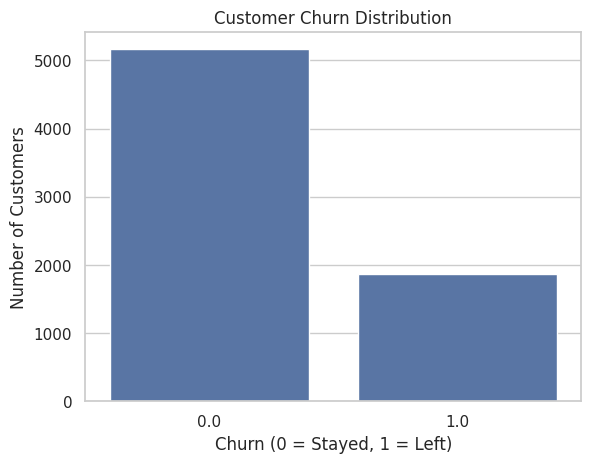

In [49]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')

plt.show()

In [50]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0.0,73.421502
1.0,26.578498


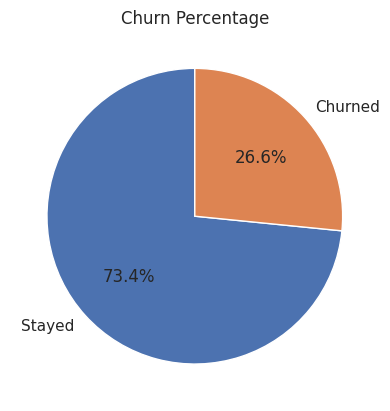

In [51]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Stayed','Churned'],
    startangle=90
)

plt.title('Churn Percentage')
plt.ylabel('')
plt.show()

## Churn Analysis by Categorical Variables

In this step, we explore how customer churn varies across different categorical variables such as:

- Gender
- Contract type
- Payment method
- Internet service

Analyzing churn across these categories helps identify patterns that may explain why customers leave the service.

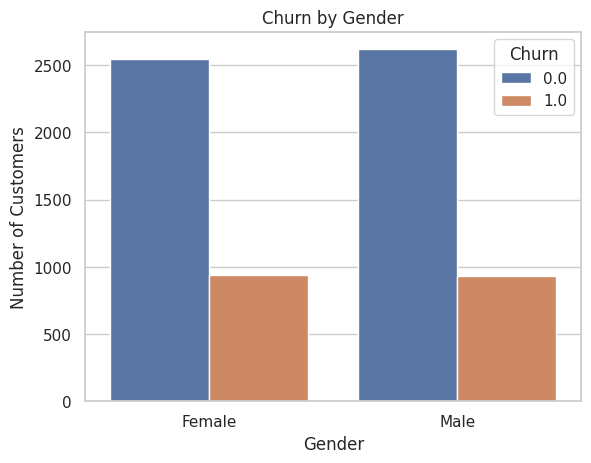

In [52]:
sns.countplot(x='gender', hue='Churn', data=df)

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

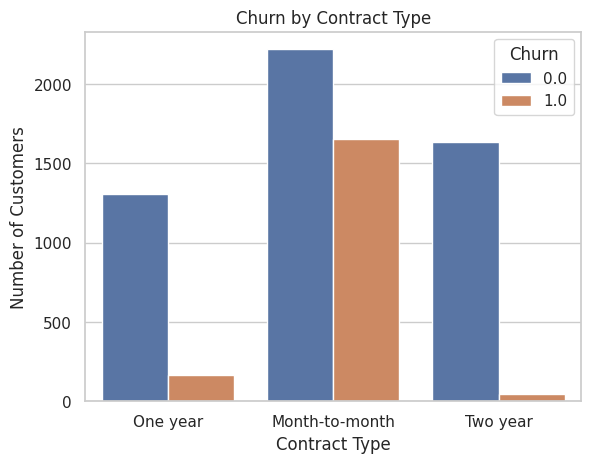

In [53]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

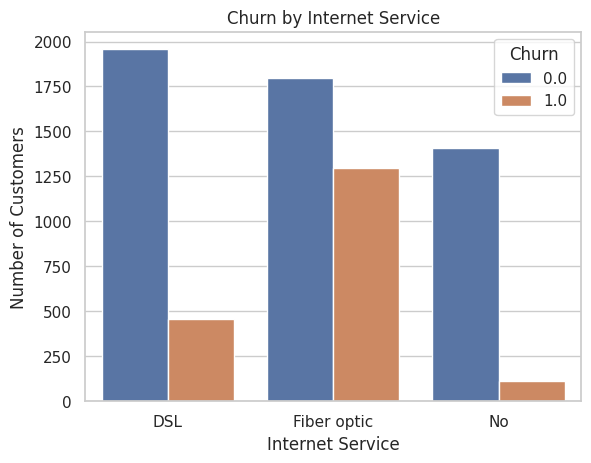

In [54]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

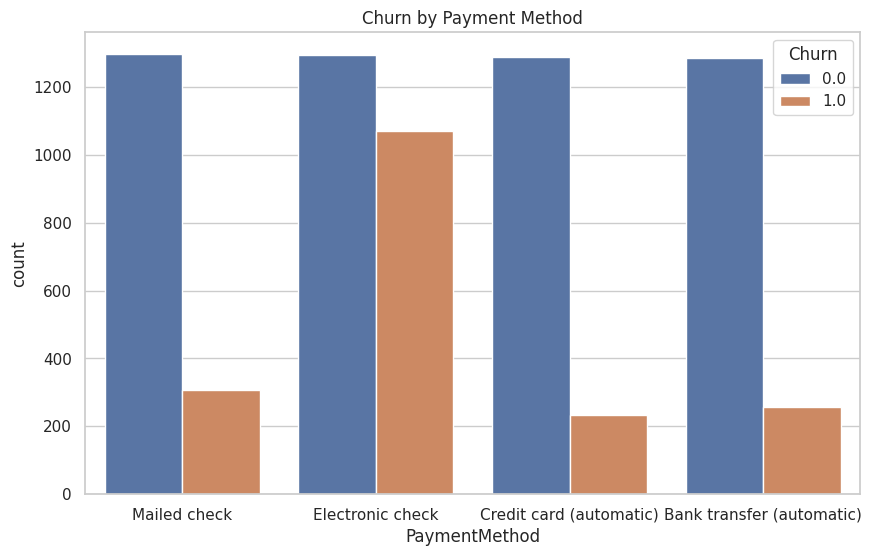

In [62]:
plt.figure(figsize=(10,6))

sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title('Churn by Payment Method')

plt.show()

### Insights

From the categorical analysis, several patterns can be observed:

- Customers with **month-to-month contracts** show higher churn rates.
- Long-term contracts (one or two years) appear to retain customers more effectively.
- Certain payment methods may be associated with higher churn rates.
- Gender does not appear to significantly affect churn behavior.

## Churn Analysis by Numerical Variables

In this step, we analyze how numerical variables such as customer tenure, monthly charges, and total charges differ between customers who churned and those who remained.

By comparing these distributions, we can identify patterns that may explain customer churn behavior.

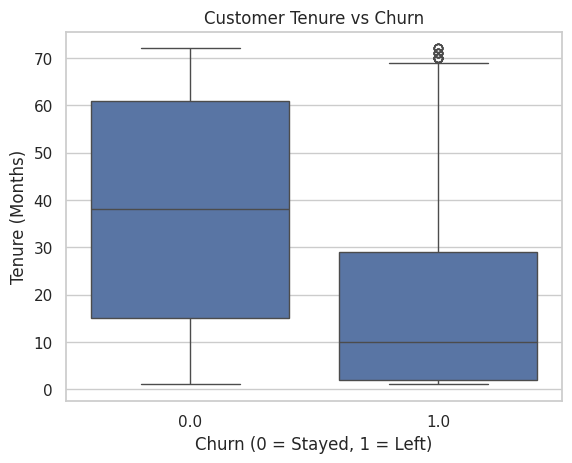

In [66]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Customer Tenure vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Tenure (Months)')

plt.show()

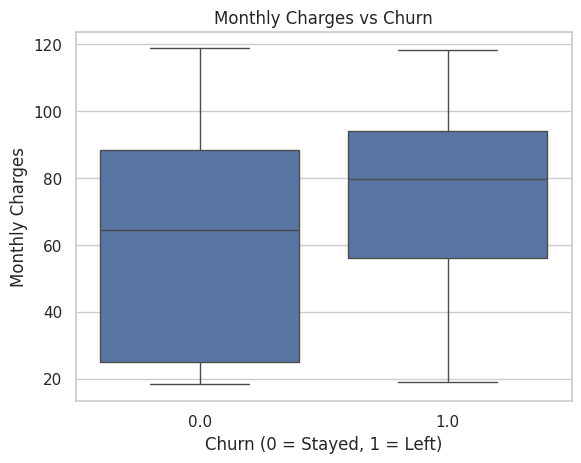

In [68]:
sns.boxplot(x='Churn', y='Charges_Monthly', data=df)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Charges')

plt.show()

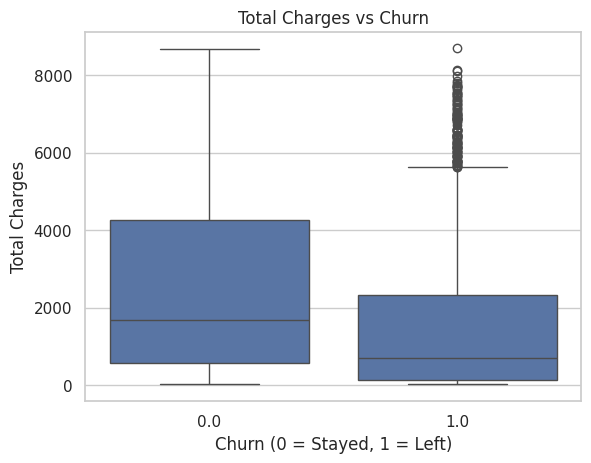

In [69]:
sns.boxplot(x='Churn', y='Charges_Total', data=df)

plt.title('Total Charges vs Churn')
plt.xlabel('Churn (0 = Stayed, 1 = Left)')
plt.ylabel('Total Charges')

plt.show()

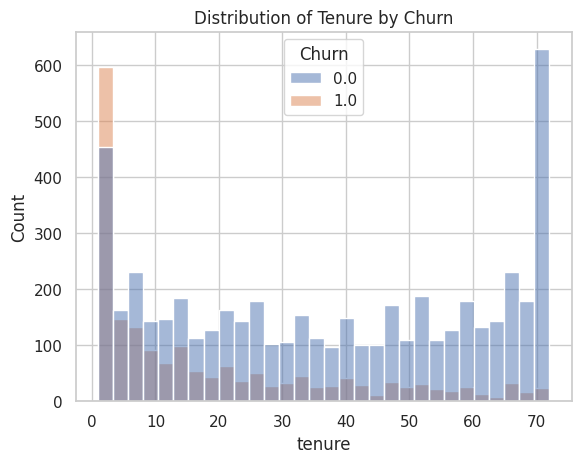

In [71]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)

plt.title('Distribution of Tenure by Churn')
plt.show()

In [73]:
df.groupby('Churn')[['tenure','Charges_Monthly','Charges_Total']].mean()

,tenure,Charges_Monthly,Charges_Total
Churn,,,
0.0,37.650010,61.307408,2555.344141
1.0,17.979133,74.441332,1531.796094


#📄Informe final

## Telecom X - Churn Analysis Report

**Introduction:**  
This analysis aims to understand the factors related to customer churn in Telecom X. Churn occurs when customers cancel their services, which can negatively affect the company's revenue. The objective of this project is to explore the dataset and identify patterns that may explain why customers leave the service.

**Data Cleaning and Preparation:**  
The dataset was imported from a JSON API and converted into a pandas DataFrame. Nested structures were normalized to obtain a flat dataset. Missing values were checked and corrected, data types were adjusted for numerical variables, and a new column called **Cuentas_Diarias** was created based on monthly charges. Some categorical variables were also standardized to ensure consistency.

**Exploratory Data Analysis:**  
Several visualizations were created to analyze churn distribution and customer behavior. The analysis included examining churn proportions, analyzing categorical variables such as gender, contract type, internet service, and payment method, as well as numerical variables like tenure, monthly charges, and total charges.

**Conclusions and Insights:**  
The analysis shows that customers with **month-to-month contracts** and **shorter tenure** tend to have higher churn rates. Additionally, customers with higher monthly charges appear to have a slightly higher probability of canceling their service.

**Recommendations:**  
Telecom X could reduce churn by encouraging long-term contracts, improving the onboarding experience for new customers, and monitoring customers with higher monthly charges. These strategies may help improve customer retention and reduce service cancellations.